# 01 - EDA profundo y preprocesamiento mejorado (unificado)

Este notebook realiza un EDA más profundo y un preprocesamiento robusto para los 6 CSV de AirBnB en `data/`.
Primero: EDA descriptivo y comparativo por ciudad (estadísticas, nulos, distribución de precios, barrios).
Después: preprocesamiento conservador y reproducible (drop nulos, outliers, imputaciones, duplicados).

In [ ]:

# Imports y ajustes
import os
from pathlib import Path
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats

pio.renderers.default = 'browser'  # fallback: abrir figuras en navegador si el renderer del notebook no está disponible
%matplotlib inline
sns.set(style="whitegrid", palette="muted")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 100

In [4]:
# Rutas y detección de archivos esperados (6 ciudades)
BASE_DIR = Path('..').resolve() if Path('.').name == 'notebooks' else Path('.')
DATA_DIR = (BASE_DIR / '../data').resolve()
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CITY_KEYS = ['london', 'madrid', 'milan', 'ny', 'sydney', 'tokyo']
csv_candidates = [p for p in DATA_DIR.iterdir() if p.suffix.lower() == '.csv']
csv_map = {}
for p in csv_candidates:
    name = p.name.lower()
    for key in CITY_KEYS:
        if key in name and key not in csv_map:
            csv_map[key] = p
            break

missing = [k for k in CITY_KEYS if k not in csv_map]
if missing:
    print('Warning: no se encontraron archivos para estas keys (esperadas):', missing)

print('Archivos detectados para procesar:')
for k,p in csv_map.items():
    print('-', k, '->', p.name)

Archivos detectados para procesar:
- london -> london_airbnb.csv
- madrid -> madrid_airbnb.csv
- milan -> milan_airbnb.csv
- ny -> NY_airbnb.csv
- sydney -> sydney_airbnb.csv
- tokyo -> tokyo_airbnb.csv


In [5]:
# Funciones reutilizables: normalización de columnas y parseo de price
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = {}
    for c in df.columns:
        nc = str(c).strip().lower()
        nc = re.sub(r'[^0-9a-zA-Z_]+', '_', nc)
        nc = nc.replace(' ', '_')
        nc = re.sub(r'_+', '_', nc)
        new_cols[c] = nc
    return df.rename(columns=new_cols)

def parse_price(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.replace(r'[\$,€]', '', regex=True)
    s = s.str.replace(r',', '', regex=True)
    s = s.str.replace('\u2009', '')
    s = s.replace(['', 'nan', 'None', 'NaN'], pd.NA)
    return pd.to_numeric(s, errors='coerce')

def load_and_normalize(path: Path, city_key: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = clean_column_names(df)
    df['city'] = city_key
    if 'price' in df.columns:
        df['price'] = parse_price(df['price'])
    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    for c in ['reviews_per_month','number_of_reviews','minimum_nights','availability_365']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

In [6]:
# Cargar los dataframes en memoria (dict) y mostrar primeras filas
dataframes = {}
for key, path in csv_map.items():
    try:
        df = load_and_normalize(path, key)
        dataframes[key] = df
        print(f'Loaded {key}:', df.shape)
    except Exception as e:
        print(f'Error loading {key} from {path}:', e)

# Mostrar una fila de ejemplo por ciudad (head)
for k, df in dataframes.items():
    print('---', k.upper(), 'head ---')
    display(df.head())

Loaded london: (85068, 17)
Loaded madrid: (19618, 17)


C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\1937741826.py:26: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Loaded milan: (18322, 16)
Loaded ny: (48895, 17)
Loaded sydney: (36662, 17)
Loaded tokyo: (11466, 15)
--- LONDON head ---


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,11551,Arty and Bright London Apartment in Zone 2,43039,Adriano,NaN,Lambeth,51.46225,-0.11732,Entire home/apt,88,3,185,2019-09-15,1.58,2,336,london
1,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56802,-0.11121,Private room,65,1,19,2019-10-07,0.17,2,365,london
2,90700,Sunny Notting Hill flat & terrace,491286,Chil,NaN,Kensington and Chelsea,51.51074,-0.19853,Entire home/apt,105,2,339,2019-07-30,3.33,2,268,london
3,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48796,-0.16898,Entire home/apt,100,30,88,2019-09-23,0.73,1,158,london
4,92399,"MODERN SELF CONTAINED ARCHITECT FLATLET, ISLIN...",497366,Andrea & Mark,NaN,Islington,51.55071,-0.08547,Private room,77,1,207,2019-10-21,2.04,2,336,london


--- MADRID head ---


...

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,ny
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,ny
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,ny
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,ny
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,ny


--- SYDNEY head ---


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,12351,Sydney City & Harbour at the door,17061,Stuart,NaN,Sydney,-33.865153,151.191896,Private room,100,2,493,2018-11-21,4.83,2,187,sydney
1,14250,Manly Harbour House,55948,Heidi,NaN,Manly,-33.800929,151.261722,Entire home/apt,471,5,1,2016-01-02,0.03,2,321,sydney
2,15253,Stunning Penthouse Apartment In Heart Of The City,59850,Morag,NaN,Sydney,-33.880455,151.216541,Private room,109,2,300,2018-11-16,3.63,2,316,sydney
3,20865,3 BED HOUSE + 1 BED STUDIO Balmain,64282,Fiona,NaN,Leichhardt,-33.859072,151.172753,Entire home/apt,450,7,15,2018-01-07,0.18,1,69,sydney
4,26174,"COZY PRIVATE ROOM, GREAT LOCATION!",110561,Amanda,NaN,Woollahra,-33.889087,151.259404,Private room,62,1,42,2018-11-23,0.45,1,140,sydney


--- TOKYO head ---


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,city
0,35303,"La Casa Gaienmae C Harajuku, Omotesando is nearby",151977,Miyuki,NaN,Shibuya Ku,35.67152,139.71203,Private room,4196,28,18,2018-07-28,0.20,tokyo
1,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71721,139.82596,Entire home/apt,10975,3,156,2019-05-21,1.65,tokyo
2,289597,Private apt in central Tokyo #203,341577,Hide&Kei,NaN,Nerima Ku,35.74267,139.65810,Entire home/apt,4196,30,107,2019-05-25,1.25,tokyo
3,370759,"Cozy flat #203, local area YET 10 mins to shib...",1573631,"Gilles,Mayumi,Taiki",NaN,Setagaya Ku,35.66344,139.65593,Entire home/apt,6994,29,99,2019-05-07,1.55,tokyo
4,700253,Private apt in central Tokyo #201,341577,Hide&Kei,NaN,Nerima Ku,35.74264,139.65832,Entire home/apt,3981,30,101,2019-05-03,1.24,tokyo


## EDA descriptivo por ciudad
A continuación se muestran resúmenes estadísticos, conteo de nulos y análisis por barrio cuando la columna exista.
Generamos también distribuciones de `price` (escala log) y boxplots para detectar visualmente outliers.

===== CITY: LONDON =====
Shape: (85068, 17)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,85068.0,NaN,NaN,NaN,23199967.979158,11551.0,14413146.25,23632006.0,33492807.75,39880297.0,11324745.656348
name,85042,82446,Double room,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,85068.0,NaN,NaN,NaN,85144423.767633,2697.0,15298559.0,47623866.0,141543527.25,307001299.0,86035324.089143
host_name,85056,14573,Veeve,1235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,85068,33,Westminster,9588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,85068.0,NaN,NaN,NaN,51.509798,51.29479,51.48561,51.514015,51.53758,51.68169,0.046341
longitude,85068.0,NaN,NaN,NaN,-0.128343,-0.49668,-0.188412,-0.125725,-0.070127,0.28539,0.093034
room_type,85068,4,Entire home/apt,47445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,85068.0,NaN,NaN,NaN,122.336766,0.0,47.0,84.0,140.0,12345.0,220.749123


,missing_frac,dtype
availability_365,0.000000,int64
calculated_host_listings_count,0.000000,int64
city,0.000000,object
host_id,0.000000,int64
host_name,0.000141,object
id,0.000000,int64
last_review,0.235177,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64


Top room_type:


room_type
Entire home/apt    47445
Private room       35882
Hotel room          1113
Shared room          628
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
Westminster               9588
Tower Hamlets             8246
Hackney                   6276
Kensington and Chelsea    6018
Camden                    5972
Islington                 5108
Southwark                 4893
Lambeth                   4854
Wandsworth                4272
Hammersmith and Fulham    4210
Name: count, dtype: int64

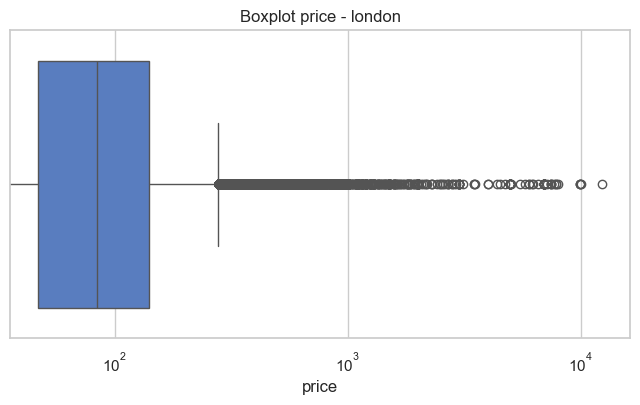

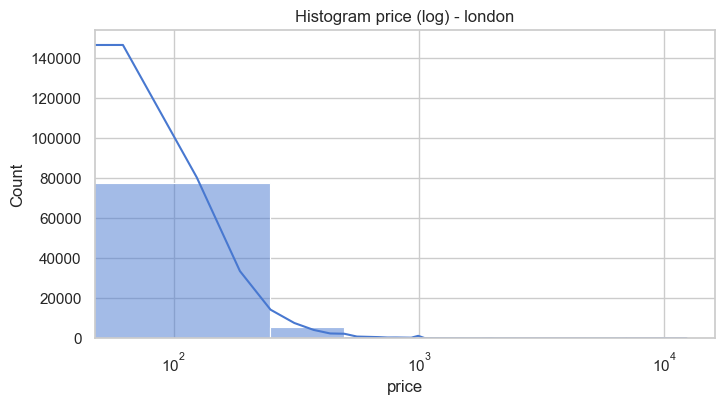

C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



===== CITY: MADRID =====
Shape: (19618, 17)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,19618.0,NaN,NaN,NaN,29122003.820012,6369.0,19034239.0,31875060.5,40909940.5,49187791.0,13518391.708053
name,19615,18793,Habitación privada,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,19618.0,NaN,NaN,NaN,131216502.629371,7952.0,27653128.5,99018982.0,225689762.0,396428081.0,116678973.528633
host_name,19091,3900,Daniel,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,19618,21,Centro,8649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,19618,128,Embajadores,2318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,19618.0,NaN,NaN,NaN,40.420984,40.33221,40.409393,40.419735,40.43029,40.56274,0.022627
longitude,19618.0,NaN,NaN,NaN,-3.69404,-3.86391,-3.7077,-3.70112,-3.68542,-3.5319,0.028671
room_type,19618,4,Entire home/apt,11314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,19618.0,NaN,NaN,NaN,129.27174,0.0,35.0,58.0,100.0,9999.0,484.143545


,missing_frac,dtype
availability_365,0.000000,int64
calculated_host_listings_count,0.000000,int64
city,0.000000,object
host_id,0.000000,int64
host_name,0.026863,object
id,0.000000,int64
last_review,0.287338,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64


Top room_type:


room_type
Entire home/apt    11314
Private room        7809
Shared room          329
Hotel room           166
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
Embajadores        2318
Universidad        1869
Palacio            1506
Sol                1125
Justicia            951
Cortes              880
Trafalgar           371
Palos de Moguer     337
Goya                296
Argüelles           281
Name: count, dtype: int64

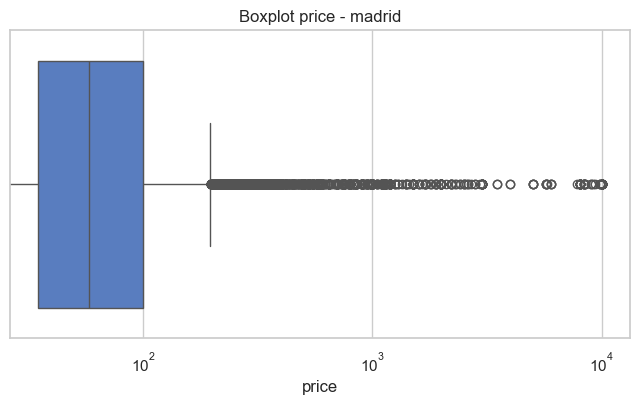

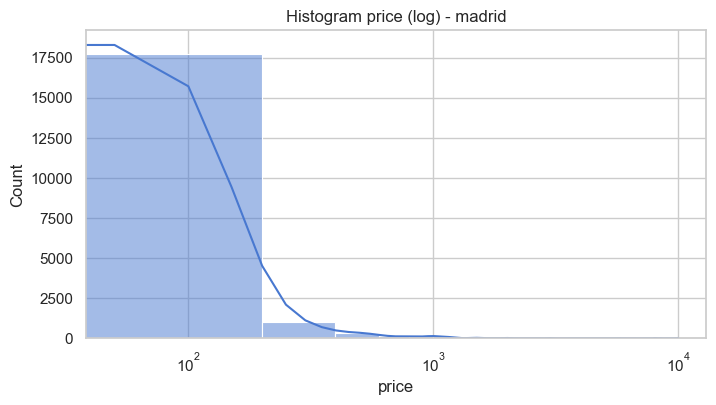

C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



===== CITY: MILAN =====
Shape: (18322, 16)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,18322.0,NaN,NaN,NaN,25871317.658007,6400.0,12140667.5,25887183.0,39267579.75,50955051.0,15257438.547718
name,18312,18050,Milan Royal Suites - Duomo Bilocale,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,18322.0,NaN,NaN,NaN,84949179.125969,1944.0,12436422.0,31413040.0,133522733.5,411720762.0,104057872.874574
host_name,18198,2917,Andrea,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,18322,87,BUENOS AIRES - VENEZIA,1373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,18322.0,NaN,NaN,NaN,45.471318,45.39505,45.454462,45.470875,45.48685,45.53985,0.020731
longitude,18322.0,NaN,NaN,NaN,9.187382,9.06068,9.168782,9.186291,9.20968,9.27528,0.029543
room_type,18322,4,Entire home/apt,13605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,18322.0,NaN,NaN,NaN,115.094913,8.0,50.0,73.5,110.0,11999.0,290.793019
minimum_nights,18322.0,NaN,NaN,NaN,5.798112,1.0,1.0,2.0,3.0,1124.0,26.68772


,missing_frac,dtype
availability_365,0.000000,int64
calculated_host_listings_count,0.000000,int64
city,0.000000,object
host_id,0.000000,int64
host_name,0.006768,object
id,0.000000,int64
last_review,0.276280,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64


Top room_type:


room_type
Entire home/apt    13605
Private room        4376
Shared room          267
Hotel room            74
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
BUENOS AIRES - VENEZIA    1373
DUOMO                     1003
NAVIGLI                    875
SARPI                      806
TICINESE                   749
LORETO                     725
BRERA                      713
CENTRALE                   689
ISOLA                      644
XXII MARZO                 584
Name: count, dtype: int64

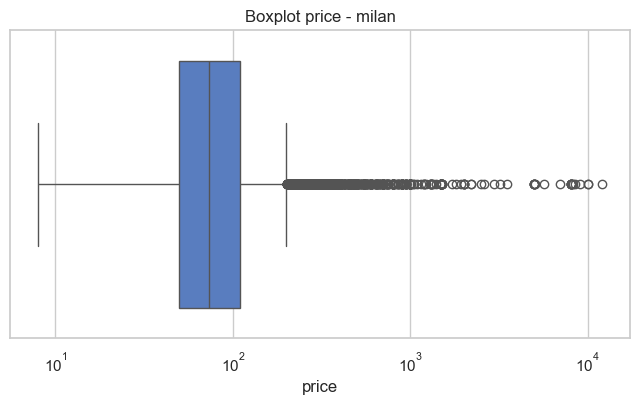

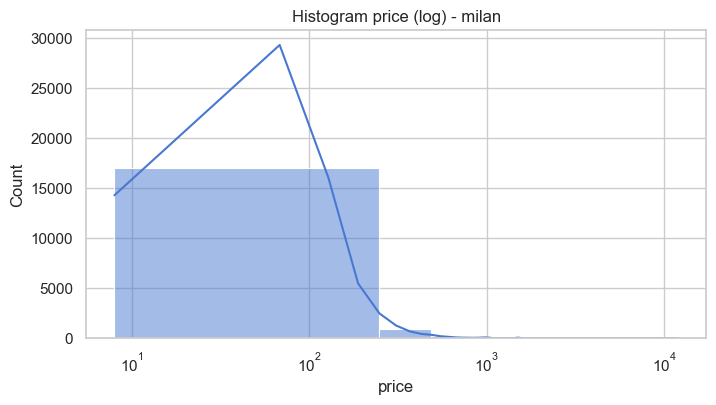

C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



===== CITY: NY =====
Shape: (48895, 17)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,48895.0,NaN,NaN,NaN,19017143.23618,2539.0,9471945.0,19677284.0,29152178.5,36487245.0,10983108.38561
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,2438.0,7822033.0,30793816.0,107434423.0,274321313.0,78610967.032667
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,40.49979,40.6901,40.72307,40.763115,40.91306,0.05453
longitude,48895.0,NaN,NaN,NaN,-73.95217,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299,0.046157
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,0.0,69.0,106.0,175.0,10000.0,240.15417


,missing_frac,dtype
availability_365,0.000000,int64
calculated_host_listings_count,0.000000,int64
city,0.000000,object
host_id,0.000000,int64
host_name,0.000429,object
id,0.000000,int64
last_review,0.205583,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64


Top room_type:


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64

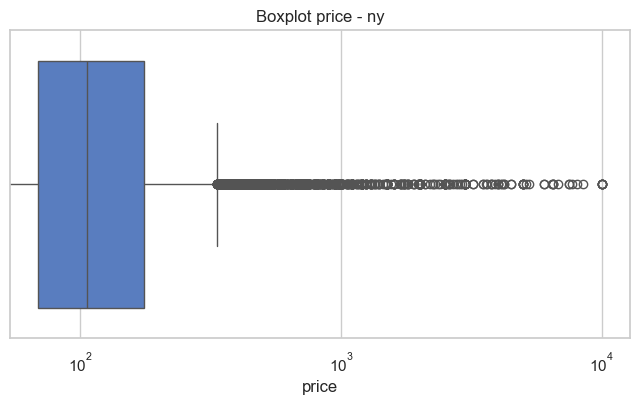

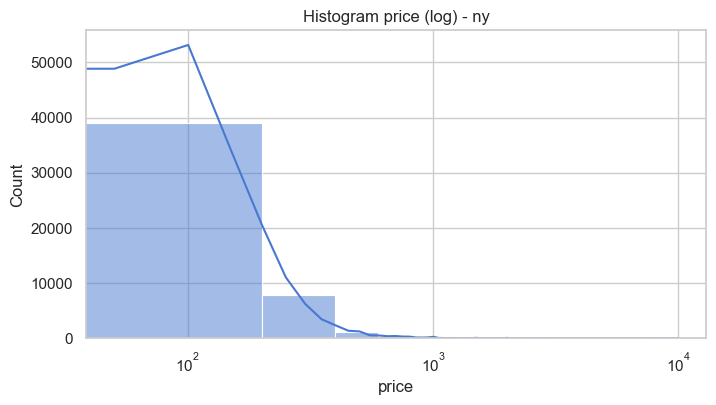

C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



===== CITY: SYDNEY =====
Shape: (36662, 17)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,36662.0,NaN,NaN,NaN,18520829.652256,12351.0,11704613.5,20273497.0,25244052.5,30593866.0,8473884.00175
name,36650,35857,Home away from home,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,36662.0,NaN,NaN,NaN,65616201.864137,8346.0,15060221.0,41348188.0,105360535.5,229479027.0,63745327.975146
host_name,36656,7874,David,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,36662,38,Sydney,9241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,36662.0,NaN,NaN,NaN,-33.863112,-34.135212,-33.898444,-33.882486,-33.832072,-33.389728,0.071501
longitude,36662.0,NaN,NaN,NaN,151.204259,150.642903,151.179678,151.215923,151.261413,151.339811,0.083529
room_type,36662,3,Entire home/apt,22918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,36662.0,NaN,NaN,NaN,207.689597,0.0,80.0,136.0,223.0,14999.0,323.818795


,missing_frac,dtype
availability_365,0.000000,int64
calculated_host_listings_count,0.000000,int64
city,0.000000,object
host_id,0.000000,int64
host_name,0.000164,object
id,0.000000,int64
last_review,0.325596,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64


Top room_type:


room_type
Entire home/apt    22918
Private room       13115
Shared room          629
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
Sydney          9241
Waverley        5467
Randwick        3346
Manly           1800
Warringah       1794
Woollahra       1573
North Sydney    1370
Marrickville    1252
Pittwater       1192
Leichhardt       999
Name: count, dtype: int64

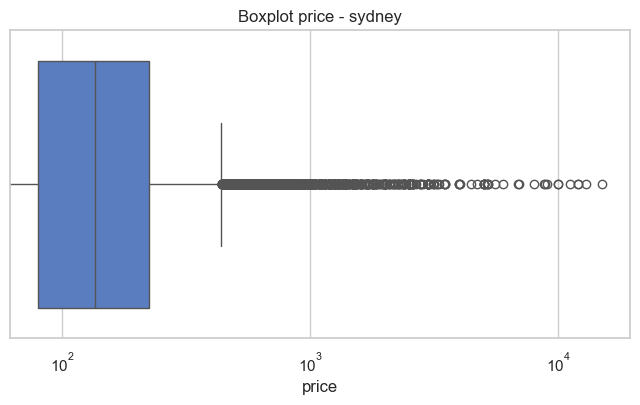

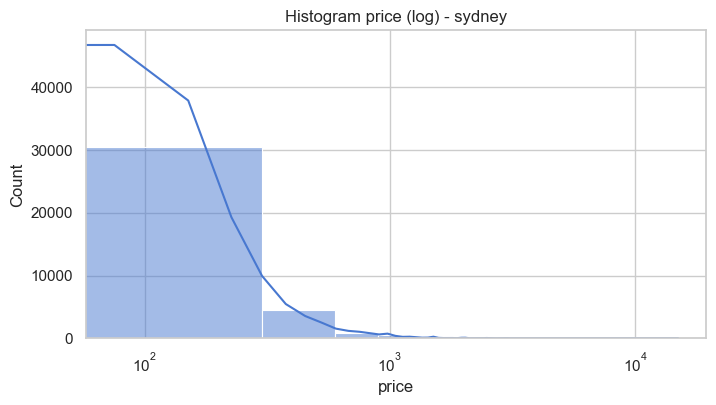

C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



===== CITY: TOKYO =====
Shape: (11466, 15)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,11466.0,NaN,NaN,NaN,26405454.974359,35303.0,22152513.75,28418728.5,32224162.75,36086604.0,7565211.616192
name,11466,10810,Near Ueno#Cozy Hotel#6min to Subway#40min airport,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,11466.0,NaN,NaN,NaN,139977564.720565,151977.0,57831714.0,150232625.0,213589572.25,271413041.0,80642889.819763
host_name,11450,2054,M-1 Tokyo,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,11466,56,Shinjuku Ku,1882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,11466.0,NaN,NaN,NaN,35.687159,27.07233,35.67962,35.70191,35.724215,35.83243,0.217853
longitude,11466.0,NaN,NaN,NaN,139.734537,139.13002,139.698975,139.729165,139.78427,142.20288,0.092771
room_type,11466,3,Entire home/apt,7463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,11466.0,NaN,NaN,NaN,14984.697977,0.0,6026.0,10007.0,17216.0,1000046.0,33273.448191


,missing_frac,dtype
city,0.000000,object
host_id,0.000000,int64
host_name,0.001395,object
id,0.000000,int64
last_review,0.146259,datetime64[ns]
latitude,0.000000,float64
longitude,0.000000,float64
minimum_nights,0.000000,int64
name,0.000000,object
neighbourhood,0.000000,object


Top room_type:


room_type
Entire home/apt    7463
Private room       3004
Shared room         999
Name: count, dtype: int64

Top neighbourhoods:


neighbourhood
Shinjuku Ku    1882
Taito Ku       1670
Toshima Ku     1228
Sumida Ku       879
Shibuya Ku      854
Ota Ku          598
Minato Ku       551
Chuo Ku         448
Setagaya Ku     305
Suginami Ku     299
Name: count, dtype: int64

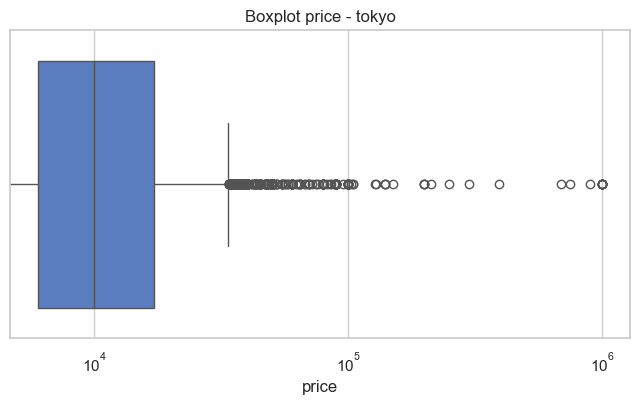

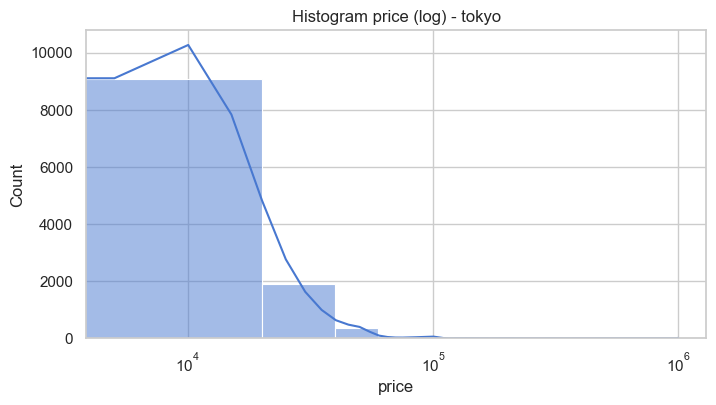

EDA descriptivo completado (revisa salidas por ciudad).


C:\Users\yeder\AppData\Local\Temp\ipykernel_17940\2279265391.py:34: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [7]:
def df_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)
    types = df.dtypes.astype(str)
    return pd.DataFrame({'missing_frac': miss, 'dtype': types})

for key, df in dataframes.items():
    print('===== CITY:', key.upper(), '=====')
    print('Shape:', df.shape)
    display(df.describe(include='all').T)
    display(df_missing_summary(df).head(10))
    # Top room types y neighbourhoods si existen
    if 'room_type' in df.columns:
        print('Top room_type:')
        display(df['room_type'].value_counts().head(10))
    if 'neighbourhood' in df.columns:
        print('Top neighbourhoods:')
        display(df['neighbourhood'].value_counts().head(10))
    # Price plots (if exists)
    if 'price' in df.columns and not df['price'].dropna().empty:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df['price'].dropna())
        plt.title(f'Boxplot price - {key}')
        plt.xscale('log')
        plt.show()
        plt.figure(figsize=(8,4))
        sns.histplot(df['price'].dropna(), bins=50, kde=True)
        plt.xscale('log')
        plt.title(f'Histogram price (log) - {key}')
        plt.show()
    # Map scatter si hay lat/lon
    if set(['latitude','longitude']).issubset(df.columns):
        sub = df.dropna(subset=['latitude','longitude'])
        if not sub.empty and len(sub) > 10:
            fig = px.scatter_mapbox(sub.sample(min(1000,len(sub))), lat='latitude', lon='longitude', color='price' if 'price' in sub.columns else None, size='price' if 'price' in sub.columns else None, zoom=10, mapbox_style='open-street-map', title=f'Locations sample - {key}')
            fig.show()

print('EDA descriptivo completado (revisa salidas por ciudad).')

## Preprocesamiento mejorado
Reglas aplicadas:
- Eliminar filas con >50% nulos (configurable).
- Eliminar duplicados exactos.
- Eliminar registros con `price` no positivo o nulo (si `price` es esencial).
- Marcar outliers por IQR y por z-score sobre log(price).
- Imputaciones conservadoras: `reviews_per_month` -> 0; `availability_365` -> mediana.
Puedes ajustar `drop_thresh` y los umbrales de z-score según necesidad.

In [8]:
# Función de preprocesamiento (como antes, reunida aquí)
def preprocess_df(df: pd.DataFrame, drop_thresh: float = 0.5, essential_cols=None) -> pd.DataFrame:
    df = df.copy()
    # eliminar filas con demasiados nulos
    row_null_frac = df.isna().mean(axis=1)
    df = df.loc[row_null_frac <= drop_thresh].copy()
    # eliminar duplicados exactos
    df = df.drop_duplicates()
    # columnas esenciales
    if essential_cols is None:
        essential_cols = ['price']
    for c in essential_cols:
        if c in df.columns:
            df = df.loc[df[c].notna()]
    # eliminar precios no positivos
    if 'price' in df.columns:
        df = df.loc[df['price'] > 0]
    # marcar outliers por IQR
    if 'price' in df.columns:
        s = df['price'].dropna()
        q1 = s.quantile(0.25); q3 = s.quantile(0.75); iqr = q3 - q1
        lower = q1 - 1.5 * iqr; upper = q3 + 1.5 * iqr
        df['price_outlier_iqr'] = df['price'].apply(lambda x: True if pd.notna(x) and (x < lower or x > upper) else False)
        # z-score (robusto sobre log(price))
        df['price_log'] = df['price'].apply(lambda x: math.log(x) if pd.notna(x) and x>0 else np.nan)
        try:
            non_na = df['price_log'].dropna()
            z = pd.Series(stats.zscore(non_na), index=non_na.index)
            df.loc[z.index, 'price_zscore'] = z
        except Exception:
            df['price_zscore'] = np.nan
        df['price_outlier_z'] = df['price_zscore'].abs() > 3
    # imputaciones conservadoras
    if 'reviews_per_month' in df.columns:
        df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    if 'availability_365' in df.columns:
        df['availability_365'] = df['availability_365'].fillna(df['availability_365'].median())
    if 'room_type' in df.columns:
        df['room_type'] = df['room_type'].astype(str).str.lower().str.strip()
    return df

In [9]:
# Aplicar preprocesamiento y guardar los artefactos procesados
processed_paths = []
for key in CITY_KEYS:
    if key not in dataframes:
        print(f'Skipping {key}: file not found')
        continue
    df = dataframes[key]
    df2 = preprocess_df(df, drop_thresh=0.5, essential_cols=['price'])
    # Agregados por barrio/neighbourhood (si existe la columna)
    if 'neighbourhood' in df2.columns:
        agg = df2.groupby('neighbourhood').agg(
            listings=('id','count') if 'id' in df2.columns else ('price','count'),
            price_mean=('price','mean'),
            price_median=('price','median'),
            reviews_mean=('reviews_per_month','mean') if 'reviews_per_month' in df2.columns else ('price','mean')
        ).reset_index()
        agg_path = PROCESSED_DIR / f'agg_neighbourhood_{key}.csv'
        agg.to_csv(agg_path, index=False)
    # Guardar processed csv
    out_path = PROCESSED_DIR / f'processed_{key}.csv'
    df2.to_csv(out_path, index=False)
    processed_paths.append(out_path)
    print(f'Saved processed {key} ->', out_path)

# Comprobación final: exactamente 6 processed files (o aviso)
if len(processed_paths) != len(CITY_KEYS):
    print('Warning: número de processed files != 6. Found:', len(processed_paths))
else:
    print('Saved processed files for all 6 cities.')

Saved processed london -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_london.csv
Saved processed madrid -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_madrid.csv
Saved processed milan -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_milan.csv
Saved processed ny -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_ny.csv
Saved processed sydney -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_sydney.csv
Saved processed tokyo -> C:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto_XI_data_analyst\data\processed\processed_tokyo.csv
Saved processed files for all 6 cities.


--- LONDON ---
Shape before preprocess: (85068, 17)


,value
price_mean,122.336766
price_median,84.000000
price_std,220.749123
reviews_per_month_mean,1.201995


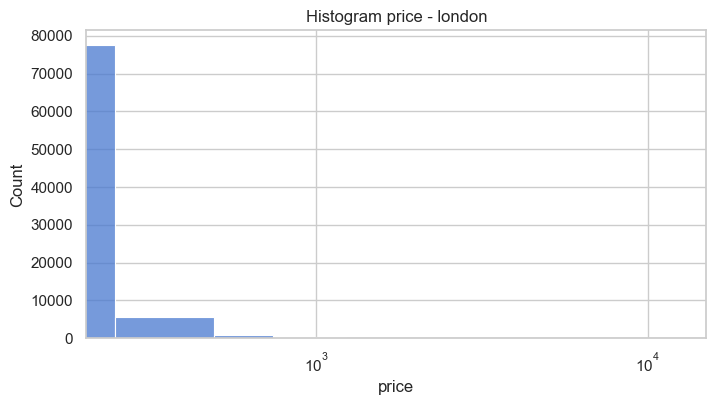

--- MADRID ---
Shape before preprocess: (19618, 17)


,value
price_mean,129.271740
price_median,58.000000
price_std,484.143545
reviews_per_month_mean,1.125958


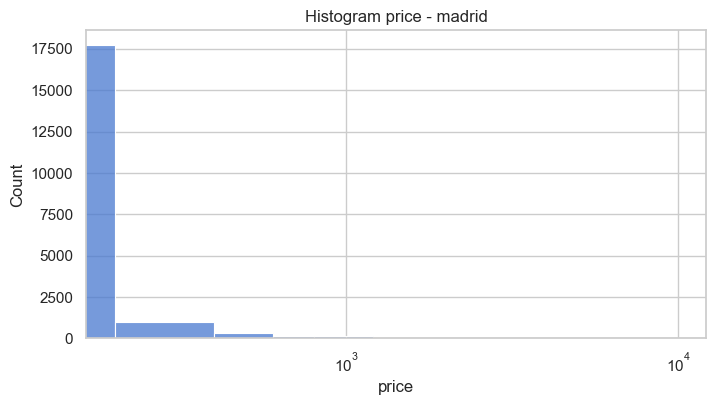

--- MILAN ---
Shape before preprocess: (18322, 16)


,value
price_mean,115.094913
price_median,73.500000
price_std,290.793019
reviews_per_month_mean,0.799344


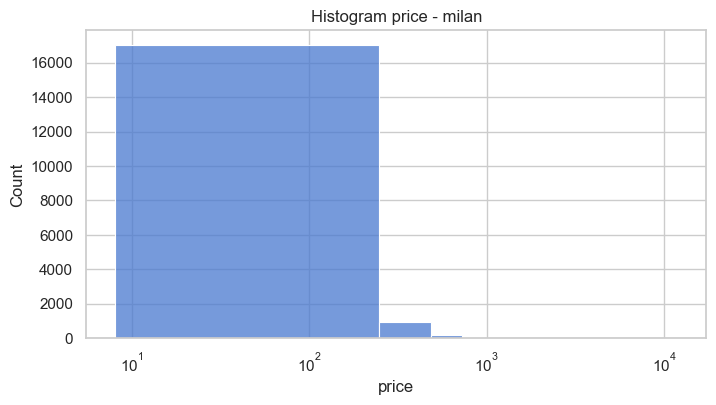

--- NY ---
Shape before preprocess: (48895, 17)


,value
price_mean,152.720687
price_median,106.000000
price_std,240.154170
reviews_per_month_mean,1.373221


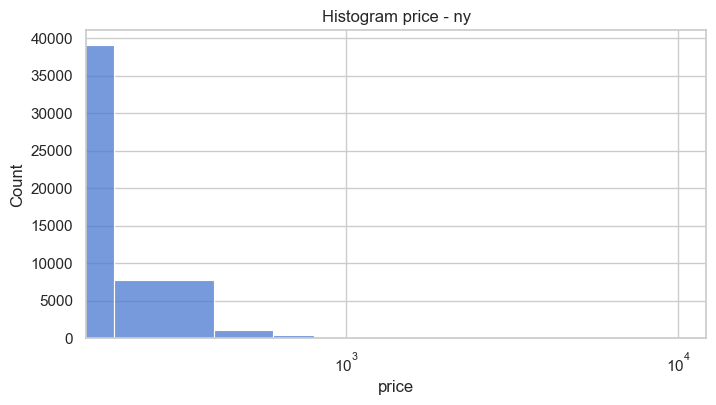

--- SYDNEY ---
Shape before preprocess: (36662, 17)


,value
price_mean,207.689597
price_median,136.000000
price_std,323.818795
reviews_per_month_mean,1.139057


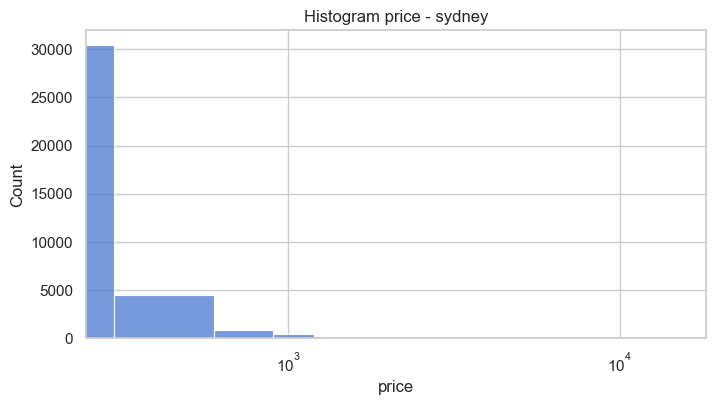

--- TOKYO ---
Shape before preprocess: (11466, 15)


,value
price_mean,14984.697977
price_median,10007.000000
price_std,33273.448191
reviews_per_month_mean,2.262540


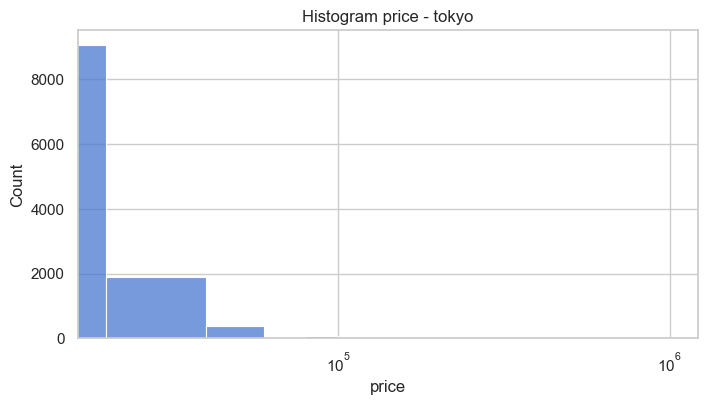

Visualizaciones rápidas generadas.


In [10]:
# Resúmenes rápidos y visualizaciones compactas por ciudad (post-load, pre/post-proc)
def quick_stats(df):
    r = {}
    if 'price' in df.columns:
        r['price_mean'] = df['price'].mean()
        r['price_median'] = df['price'].median()
        r['price_std'] = df['price'].std()
    if 'reviews_per_month' in df.columns:
        r['reviews_per_month_mean'] = df['reviews_per_month'].mean()
    return r

for key, df in dataframes.items():
    print('---', key.upper(), '---')
    print('Shape before preprocess:', df.shape)
    display(pd.DataFrame.from_dict(quick_stats(df), orient='index', columns=['value']))
    # histogram price (matplotlib)
    if 'price' in df.columns and not df['price'].dropna().empty:
        plt.figure(figsize=(8,4))
        sns.histplot(df['price'].dropna(), bins=50, kde=False)
        plt.title(f'Histogram price - {key}')
        plt.xscale('log')
        plt.show()

print('Visualizaciones rápidas generadas.')

## Notas finales y siguientes pasos
- He aplicado un preprocesamiento conservador: filas con >50% nulos se descartan, duplicados eliminados, precios no positivos descartados.
- Se marcan outliers por IQR y por z-score sobre log(price). Ajusta umbrales si quieres (p.ej. z>3 a z>4).
- Se generan agregados por `neighbourhood` cuando existe la columna.
- Archivos procesados guardados en `data/processed/processed_<city>.csv` y agregaciones en `data/processed/agg_neighbourhood_<city>.csv`.

Próximos pasos sugeridos:
1. Añadir una celda de tests que verifique que `data/processed/` contiene exactamente 6 archivos `processed_<city>.csv`.
2. Versionar este notebook con `git` (commit + push) para evitar pérdidas accidentales.
3. Opcional: crear una copia `notebooks/backup/01_eda_preprocessing_unificado.ipynb` y/o exportarlo a `.py`/.html tras validarlo.

Si quieres, añado ahora la celda de tests y los comandos automáticos de `git` listos para copiar/pegar en tu PowerShell.

## ¿Qué contienen los archivos en `data/processed/` y cuándo usarlos?

Breve guía sobre los artefactos que he generado tras el EDA y preprocesamiento:

### Resumen rápido — por qué hay 12 archivos
En la carpeta `data/processed/` veréis 12 archivos porque hemos generado 2 artefactos por cada una de las 6 ciudades:
- `processed_<city>.csv` (6 archivos)
- `agg_neighbourhood_<city>.csv` (6 archivos)

### ¿Qué es `processed_<city>.csv`?
- Contenido: el dataset a nivel de anuncio/listing, ya limpio y preprocesado.
- Limpieza aplicada (resumen): parseo/normalización de columnas, conversión numérica, eliminación de filas con demasiados nulos (configurable), drop de duplicados, eliminación de precios no positivos, imputaciones conservadoras (p. ej. `reviews_per_month = 0`), y marcado de outliers (IQR y z-score sobre `log(price)`).
- Uso recomendado:
  - Análisis detallado por anuncio (drill-down).
  - Entrenamiento de modelos (machine learning).
  - Mapas de puntos y análisis espacial fino (lat/lon por listing).
  - Auditoría y trazabilidad (reproducir pasos de limpieza y depurar por `listing_id`).

### ¿Qué es `agg_neighbourhood_<city>.csv`?
- Contenido: tabla agregada por barrio/neighbourhood con métricas resumen — por ejemplo: número de listings, precio medio y mediana, reviews promedio, etc.
- Cómo se genera: agrupando `processed_<city>.csv` por `neighbourhood` (cuando la columna existe) y calculando agregados útiles para visualización.
- Uso recomendado:
  - Dashboard (PowerBI): KPIs, rankings de barrios, coropléticos y gráficos por barrio.
  - Visualizaciones rápidas y paneles interactivos (mejor rendimiento que calcular agregaciones en tiempo real).
  - Tablas y mapas coropléticos que requieren valores agregados por zona.

### Qué hemos hecho para PowerBI: crear un único `agg_all_cities.csv`
He añadido un script (`scripts/build_powerbi_agg.py`) que combina los 6 archivos `agg_neighbourhood_<city>.csv` en un único fichero listo para PowerBI:
- Lee todos los `agg_neighbourhood_*.csv` desde `data/processed/` (o desde `data/processed/agg/` si movéis los agregados).
- Normaliza nombres de columna básicos (`lower`, `replace spaces`) y añade la columna `city` extrayéndola del nombre del fichero.
- Concatena todos los dataframes y guarda `data/powerbi/agg_all_cities.csv` y un pequeño `agg_all_cities_report_<timestamp>.csv` con filas por archivo.

### Pasos recomendados para usar `agg_all_cities.csv` en PowerBI
1. Ejecutar el script desde la raíz del repo (en el mismo entorno Python donde ejecutaste el notebook):
```powershell
python .\scripts\build_powerbi_agg.py
```
(O con `--versioned` para añadir timestamp al nombre de salida, o con `--source-dir` si los agg están en otra carpeta).
2. Abrir PowerBI Desktop -> Get Data -> Text/CSV -> seleccionar `data/powerbi/agg_all_cities.csv`.
3. Crear un Slicer (filtro) sobre la columna `city` para permitir que los usuarios seleccionen una ciudad y filtren todo el reporte.
4. Usar `neighbourhood` para mapas coropléticos o barras; usar las columnas `price_mean`, `price_median`, `listings`, `reviews_mean` para KPIs y visuales.
5. (Opcional) Para drill-through o análisis puntual: importar también `processed_<city>.csv` o generar un `processed_all_cities.csv` combinado y crear relaciones por `city`/`neighbourhood`.

### Ventajas de este enfoque
- Evitas importar 6 archivos por separado: un único fichero simplifica el pipeline en PowerBI.
- Permite slicers/filtrado por `city` y comparativas entre ciudades sin más transformaciones.
- Mejora el rendimiento y facilita refrescos en el servicio.

Si queréis, puedo añadir al notebook una celda que ejecute el script automáticamente (y muestre el conteo final de filas), o crear también el `processed_all_cities.csv` para drill-through. Dime qué prefieres y lo aplico.

### Qué hemos hecho para PowerBI: crear un único `processed_all_cities.csv` (detalle para drill-through)

Además de `agg_all_cities.csv`, he añadido un script (`scripts/build_powerbi_processed.py`) que combina los seis archivos `processed_<city>.csv` en un único fichero detallado y consistente: `data/powerbi/processed_all_cities.csv`.

Por qué es útil:
- Permite drill-through desde vistas agregadas (`agg_all_cities.csv`) a nivel de listing sin tener que importar seis ficheros por separado.
- Simplifica las relaciones en PowerBI: usa `city` y `neighbourhood` para enlazar resumen y detalle.
- Homogeneiza el esquema: columnas faltantes se rellenan con NULLs para evitar errores al importar/actualizar.

Cómo crearlo localmente (desde la raíz del repo):
```powershell
python .\scripts\build_powerbi_processed.py
```

Archivos que escribirá:
- `data/powerbi/processed_all_cities.csv`
- `data/powerbi/processed_all_cities_report_<timestamp>.csv` (resumen por fichero)

Después, importa `data/powerbi/processed_all_cities.csv` en PowerBI y crea relaciones con `agg_all_cities.csv` usando `city` y/o `neighbourhood`. Configura una página de Drill-through en PowerBI que acepte `neighbourhood` (o `city`) como clave para que los usuarios puedan ir de KPIs agregados a los detalles por anuncio.

---
